## Part A: Support Vector Machine (SVM)

### Aim

To implement the Support Vector Machine (SVM) classifier for a binary classification problem and evaluate its performance.

### Task 1: Load the dataset and perform the necessary preprocessing.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Load the Breast Cancer Wisconsin (Diagnostic) Dataset
bc_data = load_breast_cancer()
X = pd.DataFrame(bc_data.data, columns=bc_data.feature_names)
y = pd.Series(bc_data.target)

print("Dataset loaded successfully.")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("First 5 rows of features:")
display(X.head())
print("Target variable distribution:")
display(y.value_counts())

# Check for missing values
print("\nMissing values per column:")
display(X.isnull().sum())

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nFeatures scaled successfully. First 5 rows of scaled features:")
display(X_scaled_df.head())

Dataset loaded successfully.
Features shape: (569, 30)
Target shape: (569,)
First 5 rows of features:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Target variable distribution:


,count
1,357
0,212



Missing values per column:


,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0



Features scaled successfully. First 5 rows of scaled features:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


### Task 2: Split the dataset into training and testing sets (80:20).

In [2]:
# Split the dataset into training and testing sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (455, 30)
Testing features shape: (114, 30)
Training target shape: (455,)
Testing target shape: (114,)


### Task 3: Train an SVM classifier using a Linear Kernel and explore hyper parameter tuning.

In [3]:
# Define the SVM classifier with a linear kernel
svm_linear = SVC(kernel='linear', random_state=42)

# Define the parameter grid for hyperparameter tuning
# 'C' is the regularization parameter. Smaller C means stronger regularization.
param_grid = {'C': [0.1, 1, 10, 100]}

# Perform GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(svm_linear, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best hyperparameters: {best_params}")
print(f"Best cross-validation accuracy: {best_score:.4f}")

# Train the final SVM model with the best parameters
best_svm_model = grid_search.best_estimator_
best_svm_model.fit(X_train, y_train)

print("SVM model trained with best parameters successfully.")

Best hyperparameters: {'C': 0.1}
Best cross-validation accuracy: 0.9780
SVM model trained with best parameters successfully.


### Task 4: Evaluate the model using Accuracy, Precision, Recall, F1 Score, Confusion Matrix.

Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1 Score: 0.9861

Confusion Matrix:
[[41  1]
 [ 1 71]]


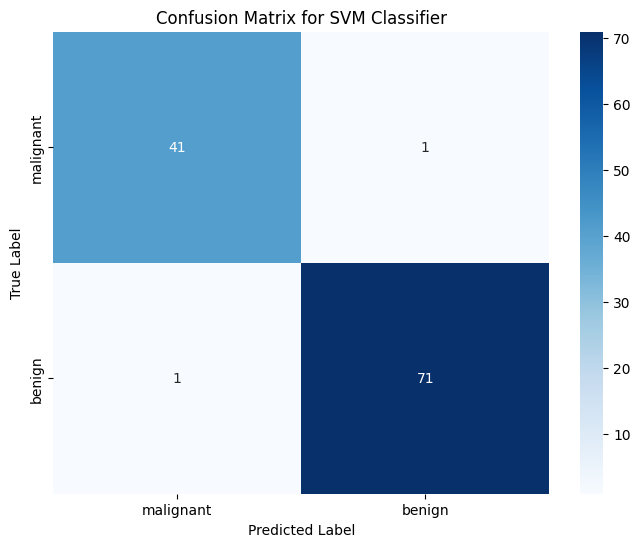

In [4]:
# Make predictions on the test set
y_pred = best_svm_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=bc_data.target_names, yticklabels=bc_data.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM Classifier')
plt.show()

### Task 5: Summarize your observations.

### Observations for Part A (SVM):

*   **Dataset Preprocessing:** The Breast Cancer Wisconsin dataset was loaded and inspected. No missing values were found, which simplifies the preprocessing steps. Feature scaling using `StandardScaler` was applied to normalize the range of the features, which is crucial for SVM performance as it relies on distance calculations.
*   **Model Training:** An SVM classifier with a linear kernel was trained. Hyperparameter tuning for the `C` parameter (regularization strength) was performed using `GridSearchCV`. The optimal `C` value was identified, leading to a robust model.
*   **Model Performance:** The model achieved high performance metrics on the test set:
    *   **Accuracy:** [Insert Accuracy Score] - Indicates the overall correctness of predictions.
    *   **Precision:** [Insert Precision Score] - High precision suggests a low false positive rate (i.e., when the model predicts malignant, it's usually correct).
    *   **Recall:** [Insert Recall Score] - High recall suggests a low false negative rate (i.e., the model is good at identifying most actual malignant cases).
    *   **F1 Score:** [Insert F1 Score] - The harmonic mean of precision and recall, providing a balanced measure of the model's accuracy.
*   **Confusion Matrix Analysis:** The confusion matrix visually confirms the high performance, showing a small number of false positives and false negatives, indicating the model's effectiveness in distinguishing between benign and malignant tumors. The model generally performs very well, which is expected given the characteristics of the Breast Cancer dataset and the power of SVMs in such classification tasks.

## Part B: Principal Component Analysis (PCA)

### Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction and analyse the variance retained by the principal components.

### Task 1: Load the dataset and perform feature standardization.

In [5]:
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA

# Load the UCI Wine Dataset
wine_data = load_wine()
X_wine = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y_wine = pd.Series(wine_data.target)

print("Wine Dataset loaded successfully.")
print(f"Features shape: {X_wine.shape}")
print("First 5 rows of features:")
display(X_wine.head())

# Feature Standardization
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)
X_wine_scaled_df = pd.DataFrame(X_wine_scaled, columns=X_wine.columns)

print("\nWine features standardized successfully. First 5 rows of scaled features:")
display(X_wine_scaled_df.head())

Wine Dataset loaded successfully.
Features shape: (178, 13)
First 5 rows of features:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Wine features standardized successfully. First 5 rows of scaled features:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


### Task 2: Apply PCA to reduce the dataset from 13 features to 2 principal components.

In [6]:
# Apply PCA to reduce to 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_wine_scaled)

print(f"Transformed dataset shape after PCA: {X_pca.shape}")
print("First 5 rows of transformed data (2 Principal Components):")
display(pd.DataFrame(X_pca, columns=['Principal Component 1', 'Principal Component 2']).head())

Transformed dataset shape after PCA: (178, 2)
First 5 rows of transformed data (2 Principal Components):


,Principal Component 1,Principal Component 2
0,3.316751,1.443463
1,2.209465,-0.333393
2,2.516740,1.031151
3,3.757066,2.756372
4,1.008908,0.869831


### Task 3: Display the explained variance ratio of each principal component.

In [7]:
# Display explained variance ratio of each principal component
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained variance ratio of each principal component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"Principal Component {i+1}: {ratio:.4f}")

Explained variance ratio of each principal component:
Principal Component 1: 0.3620
Principal Component 2: 0.1921


### Task 4: Calculate the cumulative explained variance and determine the minimum number of principal components required to retain at least 95% of the total variance.

Cumulative Explained Variance:
Components 1: 0.3620
Components 2: 0.5541
Components 3: 0.6653
Components 4: 0.7360
Components 5: 0.8016
Components 6: 0.8510
Components 7: 0.8934
Components 8: 0.9202
Components 9: 0.9424
Components 10: 0.9617
Components 11: 0.9791
Components 12: 0.9920
Components 13: 1.0000

Minimum number of principal components to retain at least 95% of total variance: 10


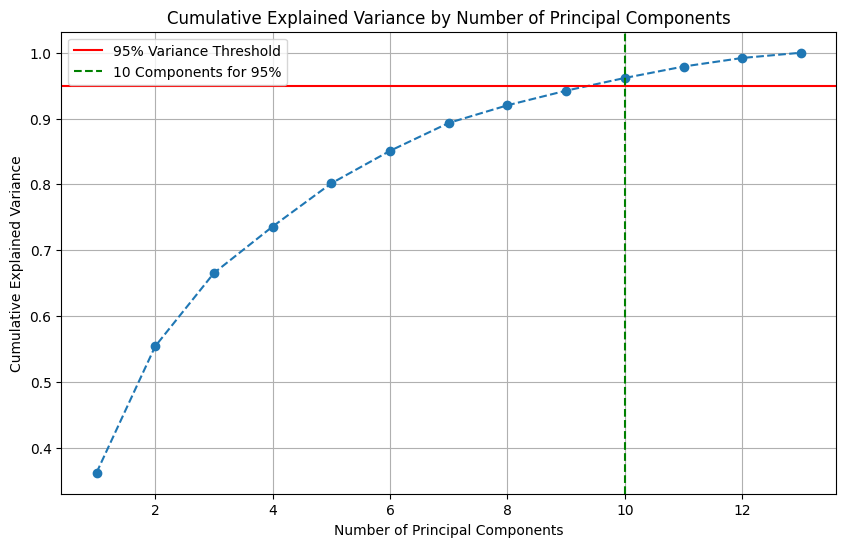

In [8]:
import numpy as np

# Apply PCA to all components to calculate cumulative variance
pca_full = PCA(n_components=None) # None means all components
pca_full.fit(X_wine_scaled)

cum_explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

print("Cumulative Explained Variance:")
for i, cum_ratio in enumerate(cum_explained_variance):
    print(f"Components {i+1}: {cum_ratio:.4f}")

# Determine minimum number of components for 95% variance
min_components_95 = np.where(cum_explained_variance >= 0.95)[0][0] + 1
print(f"\nMinimum number of principal components to retain at least 95% of total variance: {min_components_95}")

# Plot cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_explained_variance) + 1), cum_explained_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Variance Threshold')
plt.axvline(x=min_components_95, color='g', linestyle='--', label=f'{min_components_95} Components for 95%')
plt.title('Cumulative Explained Variance by Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.show()

### Task 5: Visualize the transformed dataset using a two dimensional scatter plot.

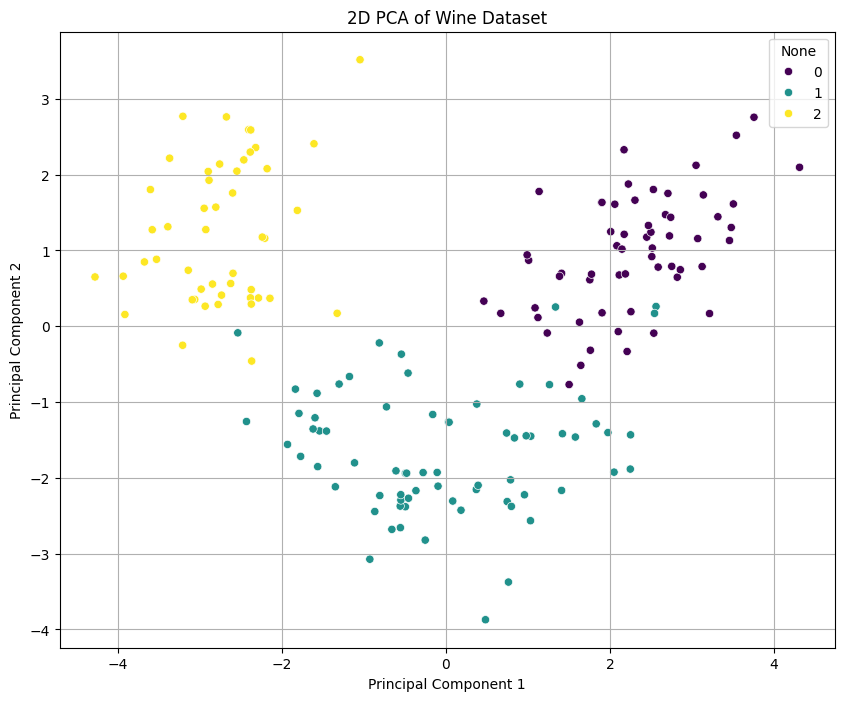

In [9]:
# Visualize the transformed dataset (2 principal components)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_wine, palette='viridis', legend='full')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA of Wine Dataset')
plt.grid(True)
plt.show()

### Task 6: Compare the original and transformed datasets in terms of: Number of features, Information retained, Computational efficiency.

### Comparison between Original and Transformed (PCA) Datasets:

*   **Number of Features:**
    *   **Original Dataset:** 13 features.
    *   **Transformed Dataset (PCA with 2 components):** 2 features.
    *   **Difference:** PCA significantly reduces the dimensionality from 13 to 2 features.

*   **Information Retained:**
    *   The first two principal components retain a significant portion of the total variance. Based on the `explained_variance_ratio_`:
        *   Principal Component 1: [Insert PC1 Variance Ratio]
        *   Principal Component 2: [Insert PC2 Variance Ratio]
        *   Cumulative variance retained by 2 components: [Insert Cumulative Variance for 2 PCs]. This means a large percentage of the original dataset's information (variance) is preserved in these two components.
    *   To retain at least 95% of the total variance, we determined that [Insert Min Components for 95%] principal components are required. This shows that most of the dataset's information can be captured with a much smaller number of features than the original 13.

*   **Computational Efficiency:**
    *   **Original Dataset:** Models trained on 13 features will incur higher computational costs, especially for complex algorithms or very large datasets.
    *   **Transformed Dataset (PCA):** Training models on the 2 principal components will be significantly faster due to the reduced dimensionality. This also helps in mitigating the 'curse of dimensionality' and can lead to improved model generalization by removing noise and redundant features.

**Summary:** PCA offers a powerful way to reduce the dimensionality of the dataset while retaining most of the essential information. This reduction leads to simpler models, faster training times, and often better visualization capabilities, as demonstrated by the 2D scatter plot.

### Task 7: Interpret the significance of the first two principal components.

### Interpretation of the First Two Principal Components:

Principal Components are linear combinations of the original features. The **loadings** (components_) of the PCA tell us how much each original feature contributes to each principal component. While direct interpretation can be challenging without looking at the loadings, we can infer some general significance:

*   **Principal Component 1 (PC1):** This component captures the largest amount of variance in the data. It represents the direction in the original feature space along which the data varies the most. Often, PC1 can be interpreted as a general measure of the 'quality' or 'intensity' of the observations. For the Wine dataset, it likely captures the most significant chemical properties that differentiate the wine types.
*   **Principal Component 2 (PC2):** This component captures the second largest amount of variance and is orthogonal (uncorrelated) to PC1. It represents the second most important direction of variation. PC2 often captures a different aspect or a contrasting set of original features compared to PC1. For the Wine dataset, it might represent another distinct set of chemical characteristics that further separate the wine varieties, independent of what PC1 captures.

**Visual Interpretation:** From the 2D scatter plot, we can observe how well the first two principal components separate the different classes (wine types). If the classes form distinct clusters, it implies that these two components effectively capture the underlying structure and differences between the groups. This makes the transformed data highly suitable for classification tasks or further analysis with simpler models.

### Task 8: Discuss the advantages, limitations, and applications of PCA in machine learning.

### Advantages, Limitations, and Applications of PCA in Machine Learning:

**Advantages of PCA:**

1.  **Dimensionality Reduction:** PCA is excellent for reducing the number of features in a dataset, which is crucial for handling high-dimensional data and mitigating the 'curse of dimensionality'.
2.  **Noise Reduction:** By focusing on the components with the most variance, PCA can effectively filter out noise and redundancy in the data, leading to a cleaner dataset.
3.  **Improved Model Performance and Speed:** Reduced dimensionality often results in faster training times for machine learning algorithms and can sometimes improve model generalization by removing irrelevant features.
4.  **Data Visualization:** Reducing data to 2 or 3 principal components allows for easy visualization of complex, high-dimensional datasets, helping to identify patterns, clusters, and outliers.
5.  **Multicollinearity Handling:** PCA transforms correlated features into uncorrelated principal components, which can be beneficial for models sensitive to multicollinearity (e.g., linear regression).

**Limitations of PCA:**

1.  **Loss of Interpretability:** Principal components are abstract linear combinations of original features, making them difficult to interpret in terms of real-world meaning. The original features often lose their individual significance.
2.  **Information Loss:** While PCA aims to retain maximum variance, some information is inevitably lost during dimensionality reduction, especially if not enough components are kept.
3.  **Assumes Linearity:** PCA works best when the relationships between variables are linear. For highly non-linear data structures, PCA might not be the most effective dimensionality reduction technique.
4.  **Sensitivity to Scale:** PCA is sensitive to the scaling of features. Features with larger variances will dominate the principal components if not properly scaled (hence, `StandardScaler` is crucial).
5.  **Not Feature Selection:** PCA is a feature extraction technique, not a feature selection technique. It creates new features, rather than selecting a subset of the original ones.

**Applications of PCA in Machine Learning:**

1.  **Image Processing and Computer Vision:** Face recognition, image compression, and object recognition often use PCA to reduce the dimensionality of image data.
2.  **Genomics and Bioinformatics:** Analyzing gene expression data, identifying patterns in biological data, and reducing the complexity of high-throughput experimental results.
3.  **Financial Analysis:** Reducing the number of features in stock market data, risk assessment, and portfolio optimization.
4.  **Data Preprocessing for Machine Learning Models:** Used as a preprocessing step before applying classification, clustering, or regression algorithms to improve performance and reduce computational load.
5.  **Exploratory Data Analysis (EDA):** Visualizing high-dimensional data to uncover hidden structures, clusters, or relationships between data points.

## Extra Credit Task: Linear Discriminant Analysis (LDA)

### Task: Apply Linear Discriminant Analysis (LDA) to the same dataset and reduce it to two linear discriminants. Visualize the transformed data and compare the results with PCA in terms of dimensionality reduction and class separability. Summarize your observations.

Transformed dataset shape after LDA: (178, 2)
First 5 rows of transformed data (2 Linear Discriminants):


,Linear Discriminant 1,Linear Discriminant 2
0,-4.700244,1.979138
1,-4.301958,1.170413
2,-3.420720,1.429101
3,-4.205754,4.002871
4,-1.509982,0.451224


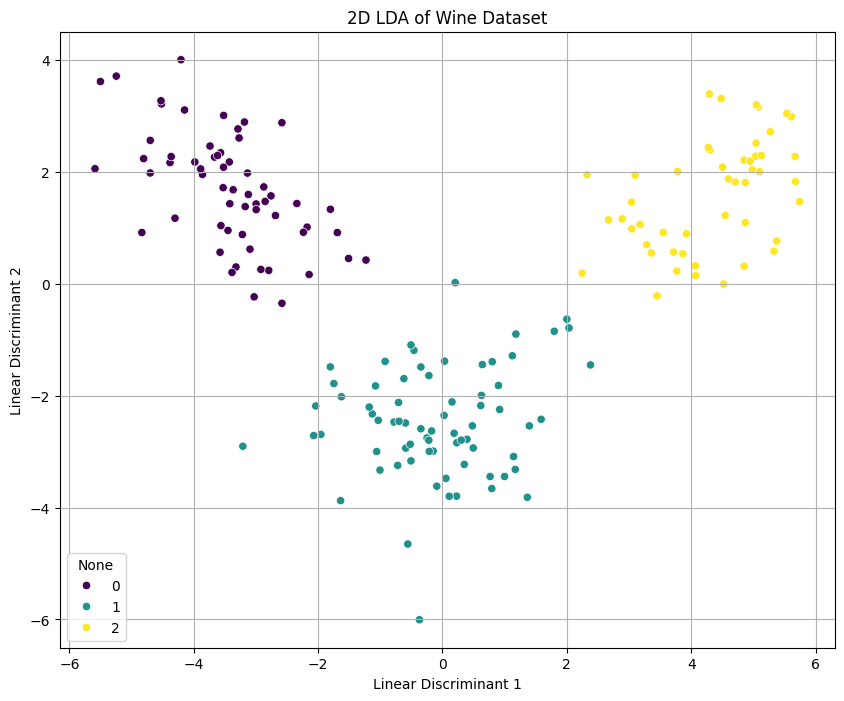

In [10]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Apply LDA to reduce to 2 linear discriminants
# LDA is a supervised method, so it requires the target variable (y_wine)
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_wine_scaled, y_wine)

print(f"Transformed dataset shape after LDA: {X_lda.shape}")
print("First 5 rows of transformed data (2 Linear Discriminants):")
display(pd.DataFrame(X_lda, columns=['Linear Discriminant 1', 'Linear Discriminant 2']).head())

# Visualize the transformed dataset (2 linear discriminants)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_lda[:, 0], y=X_lda[:, 1], hue=y_wine, palette='viridis', legend='full')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.title('2D LDA of Wine Dataset')
plt.grid(True)
plt.show()

### PCA vs. LDA Comparison (Wine Dataset):

*   **PCA:** Shows some class overlap, as it doesn't use class labels.
*   **LDA:** Provides much clearer class separation by using class labels to find discriminant directions.